Ethan Gonsalves
Roll No : 24
SE AIML

In [17]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans,AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

def fetch_indicator(code,year="2022"):
  url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
  responses=requests.get(url).json()
  data={}
  # The World Bank API returns a list. The actual data is usually in the second element (index 1).
  if len(responses) > 1 and isinstance(responses[1], list):
    for item in responses[1]: # Iterate over the actual data list
        country=item['country']['value']
        value=item['value']
        if value is not None:
            data[country]=value
  return pd.Series(data,name=code)

In [18]:
gdp=fetch_indicator( "NY.GDP.PCAP.CD")
pop=fetch_indicator("SP.POP.TOTL")
life=fetch_indicator("SP.DYN.LE00.IN")
lit=fetch_indicator("SE.ADT.LITR.ZS")


In [22]:
df = pd.DataFrame({'GDP': gdp, 'Population': pop, 'LifeExpectancy': life, 'LiteracyRate': lit})
df.dropna(inplace=True)
X = df.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss =[]

for k in range(1,11):
  km = KMeans(n_clusters=k,random_state=0, n_init=10) # Added n_init to suppress warning
  km.fit(X_scaled)
  wcss.append(km.inertia_)
print ("k\tWCSS")
for i in range(10):
     print(i+1,wcss[i])

k	WCSS
1 336.0
2 206.4371719260381
3 140.44737992159943
4 84.95472291479633
5 65.11528215592146
6 53.63698303866683
7 44.83310827208434
8 35.89925019293267
9 30.740252319035612
10 26.76287432852723


#Clustering Alogorithm

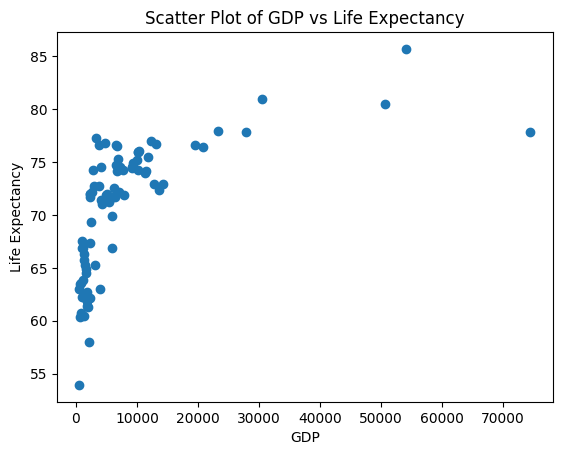

In [26]:
plt.scatter(df["GDP"], df["LifeExpectancy"])

plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.title("Scatter Plot of GDP vs Life Expectancy")
plt.show()

In [25]:
kmeans=KMeans(n_clusters=3,random_state=0)

lables_km = kmeans.fit_predict(X_scaled)

df["KMeansCluster"]= lables_km


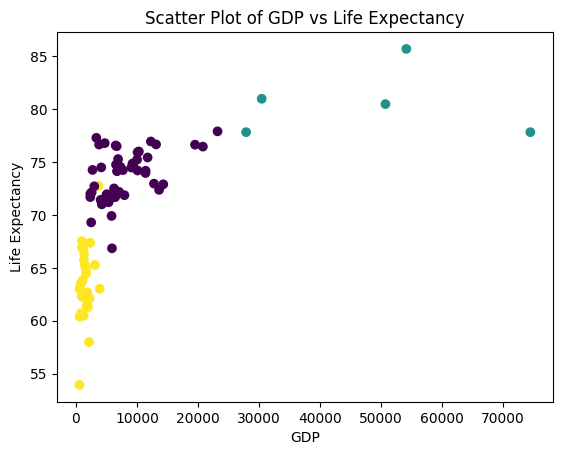

In [29]:
plt.scatter(df["GDP"], df["LifeExpectancy"],c=lables_km)

plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.title("Scatter Plot of GDP vs Life Expectancy")
plt.show()

In [30]:
hc=AgglomerativeClustering(n_clusters=3)
lables_hc=hc.fit_predict(X_scaled)

df["HierarchialCluster"]=lables_hc

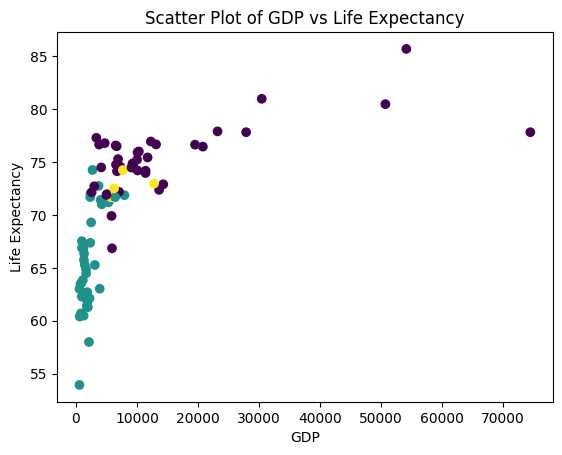

In [31]:
plt.scatter(df["GDP"], df["LifeExpectancy"],c=lables_hc)

plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.title("Scatter Plot of GDP vs Life Expectancy")
plt.show()

In [36]:
cluster_summary = df.groupby("KMeansCluster")[["GDP","Population","LifeExpectancy","LiteracyRate"]].mean()

print(cluster_summary)

                        GDP    Population  LifeExpectancy  LiteracyRate
KMeansCluster                                                          
0               8025.767775  1.178053e+09       73.801691     91.235048
1              47574.069479  2.617772e+08       80.570849     98.721762
2               1601.971896  4.854521e+08       63.478867     66.779721


In [40]:
country_name = "India"

result = df.loc[country_name]

print("country:",country_name)
print("GDP per capita :",result["GDP"])
print("Population :",result["Population"])
print("Life Expectancy :",result["LifeExpectancy"])
print("Literacy Rate :",result["LiteracyRate"])
print("KMeans Cluster :",result["KMeansCluster"])
print("Hierarchial Cluster :",result["HierarchialCluster"])

country: India
GDP per capita : 2347.44829434623
Population : 1425423212.0
Life Expectancy : 71.698
Literacy Rate : 76.3199996948242
KMeans Cluster : 0.0
Hierarchial Cluster : 1.0


In [42]:
country_name = "Brazil"

result = df.loc[country_name]

print("country:",country_name)
print("GDP per capita :",result["GDP"])
print("Population :",result["Population"])
print("Life Expectancy :",result["LifeExpectancy"])
print("Literacy Rate :",result["LiteracyRate"])
print("KMeans Cluster :",result["KMeansCluster"])
print("Hierarchial Cluster :",result["HierarchialCluster"])

country: Brazil
GDP per capita : 9281.33282136864
Population : 210306415.0
Life Expectancy : 74.872
Literacy Rate : 94.3853874531348
KMeans Cluster : 0.0
Hierarchial Cluster : 0.0


In [43]:
country_name = "Viet Nam"

result = df.loc[country_name]

print("country:",country_name)
print("GDP per capita :",result["GDP"])
print("Population :",result["Population"])
print("Life Expectancy :",result["LifeExpectancy"])
print("Literacy Rate :",result["LiteracyRate"])
print("KMeans Cluster :",result["KMeansCluster"])
print("Hierarchial Cluster :",result["HierarchialCluster"])

country: Viet Nam
GDP per capita : 4147.69777213621
Population : 99680655.0
Life Expectancy : 74.502
Literacy Rate : 96.129997253418
KMeans Cluster : 0.0
Hierarchial Cluster : 0.0


In [44]:
country_name = "Bahrain"

result = df.loc[country_name]

print("country:",country_name)
print("GDP per capita :",result["GDP"])
print("Population :",result["Population"])
print("Life Expectancy :",result["LifeExpectancy"])
print("Literacy Rate :",result["LiteracyRate"])
print("KMeans Cluster :",result["KMeansCluster"])
print("Hierarchial Cluster :",result["HierarchialCluster"])

country: Bahrain
GDP per capita : 30470.5219276023
Population : 1524693.0
Life Expectancy : 80.992
Literacy Rate : 97.870002746582
KMeans Cluster : 1.0
Hierarchial Cluster : 0.0
